# Research Proposal: Modeling Daily Parking Ticket Counts in Milwaukee

### John Eckberg

## Overview
[Milwaukee plans 65,000 more parking tickets, longer meter hours to fill transportation budget gap](https://www.jsonline.com/story/news/local/milwaukee/2025/10/21/milwaukee-aims-for-550k-parking-tickets-longer-meter-hours-in-2026/86817755007/) The city of Milwaukee relies on parking ticket revenue in order to fill budget gaps, a pressing issue given the [current deficit](https://urbanmilwaukee.com/2025/03/12/mke-county-county-faces-47-million-2026-budget-deficit/) the county is facing.
This project plans to examine how daily parking ticket activity in Milwaukee varies across time and environmental conditions. Using parking citation records obtained through a Freedom of Information Act request (2014–2022), I propose to model daily ticket counts and evaluate whether temporal, weather, and holiday-related factors explain variation in enforcement volume.

## Research Question
What is the daily rate of parking tickets issued in Milwaukee, and which factors most strongly influence that rate (if any)? In particular, I propose to test whether day of week, month/seasonality, holidays, and precipitation are associated with higher or lower daily ticket counts, including by citation type.

## Hypothesis
- Null Hypothesis: day of week, month/seasonality, holidays, and precipitation do not affect daily ticket counts.
- Alternative Hypothesis: at least one temporal or environmental factor affects daily ticket counts.

## Data Sources
- **Parking citations:** Milwaukee parking ticket records, initially loaded for 2014, with fields including `ISSUENO`, `ISSUEDATE`, `LOCATIONDESC1`, and `VIODESCRIPTION`.
- **Holiday data:** U.S. holiday dates (2004–2021) pulled from Kaggle to identify atypical traffic/parking demand days.
- **Weather data:** Open-Meteo daily weather for Milwaukee, including maximum temperature, minimum temperature, precipitation, and snowfall.


## Method
The analysis would likely focus on a geographically meaningful subset of Milwaukee (e.g., downtown, Lower East Side, Deer District). Because the response variable is a daily count, I propose that the initial model choice would be a Poisson regression GLM.

### Currently Planned Features
- **Calendar effects:** day of week, month, weekend indicator, and potential seasonal terms.
- **Cyclical time encoding:** sine/cosine transforms for month and day-of-week to preserve circular structure.
- **Holiday effects:** binary `is_holiday` indicator, one-hot encoding for major holiday names.
- **Weather exposure:** `max_temp`, `min_temp`, `precipitation`, and `snowfall`; optional threshold features (e.g., heavy precipitation day).
- **Autocorrelation:** lagged ticket count features (e.g., 1-day and 7-day lags) and short rolling averages.



In [39]:
import pandas as pd
import requests
import kagglehub 
import openpyxl
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
# Loading in the parking data [All Years now]  --  Runs in about 10 mins

#tickets_df = pd.read_excel("data/tickets_csv/2014_parking_citations_issued_open_records_request.xlsx")
data_dir = Path("data/tickets_csv")

tickets_dfs = []

for file in sorted(data_dir.glob("*.xlsx")):
    df = pd.read_excel(file)
    tickets_dfs.append(df)

tickets = pd.concat(tickets_dfs, ignore_index=True)

tickets.sample(5)

,ISSUENO,ISSUEDATE,LOCATIONDESC1,VIODESCRIPTION
3141394,113518716,2019-02-20,2974 N FRATNEY ST,NIGHT PARKING DURING DPW OPERATION
1629117,492943275,2016-08-19,937 S 29TH ST,NIGHT PARKING
145597,476246120,2014-03-26,4749 N 30TH ST,PARKED IN LOADING ZONE
4194656,125036155,2021-07-30,526 E ST PAUL AV,METER PARKING VIOLATION
512720,480441684,2014-10-23,3821 N 26TH ST,NIGHT PARKING


In [41]:
tickets.info()

<class 'pandas.DataFrame'>
RangeIndex: 4865096 entries, 0 to 4865095
Data columns (total 4 columns):
 #   Column          Dtype         
---  ------          -----         
 0   ISSUENO         int64         
 1   ISSUEDATE       datetime64[us]
 2   LOCATIONDESC1   object        
 3   VIODESCRIPTION  str           
dtypes: datetime64[us](1), int64(1), object(1), str(1)
memory usage: 148.5+ MB


In [42]:
# load in holiday data (https://www.kaggle.com/datasets/donnetew/us-holiday-dates-2004-2021)

path = kagglehub.dataset_download("donnetew/us-holiday-dates-2004-2021")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\eckbergj\.cache\kagglehub\datasets\donnetew\us-holiday-dates-2004-2021\versions\1


In [43]:
#holidays_df = pd.read_csv("C:/Users/eckbergj/.vscode/Milwaukee-Ticket-Data-Analysis/data/US Holiday Dates (2004-2021).csv")
holidays_df = pd.read_csv("data/US Holiday Dates (2004-2021).csv")

holidays_df.head(10)

,Date,Holiday,WeekDay,Month,Day,Year
0,2004-07-04,4th of July,Sunday,7,4,2004
1,2005-07-04,4th of July,Monday,7,4,2005
2,2006-07-04,4th of July,Tuesday,7,4,2006
3,2007-07-04,4th of July,Wednesday,7,4,2007
4,2008-07-04,4th of July,Friday,7,4,2008
5,2009-07-04,4th of July,Saturday,7,4,2009
6,2010-07-04,4th of July,Sunday,7,4,2010
7,2011-07-04,4th of July,Monday,7,4,2011
8,2012-07-04,4th of July,Wednesday,7,4,2012
9,2013-07-04,4th of July,Thursday,7,4,2013


In [44]:
# weather data (https://open-meteo.com/)  [extended from 2012 - 2022]
test_data = requests.get("https://archive-api.open-meteo.com/v1/archive?latitude=43.0389&longitude=-87.9065&start_date=2014-01-01&end_date=2022-12-31&daily=temperature_2m_max,temperature_2m_min,precipitation_sum,snowfall_sum&timezone=America%2FChicago")
test_data_json = test_data.json()

# minor cleaning of the weather data to get it into a dataframe
weather_df = pd.DataFrame(test_data_json['daily'])
weather_df['time'] = pd.to_datetime(weather_df['time'])
weather_df = weather_df.rename(columns={'time': 'date', 'temperature_2m_max': 'max_temp', 'temperature_2m_min': 'min_temp', 'precipitation_sum': 'precipitation','snowfall_sum': 'snowfall'})
weather_df.sample(10)


,date,max_temp,min_temp,precipitation,snowfall
2616,2021-03-01,-1.2,-13.1,0.1,0.07
2193,2020-01-03,1.9,-0.5,0.0,0.00
62,2014-03-04,-5.7,-12.0,1.4,1.05
3282,2022-12-27,-5.0,-15.1,0.0,0.00
962,2016-08-20,23.4,19.5,8.8,0.00
1064,2016-11-30,7.0,2.4,0.0,0.00
225,2014-08-14,18.8,15.2,0.0,0.00
179,2014-06-29,23.7,18.8,4.4,0.00
715,2015-12-17,2.8,-0.7,0.0,0.00
1444,2017-12-15,0.0,-6.5,0.5,0.35


In [45]:
# clean and align date keys before joining
tickets_clean = tickets.copy()
holidays_clean = holidays_df.copy()
weather_clean = weather_df.copy()

# Datetime object
tickets_clean['join_date'] = pd.to_datetime(tickets_clean['ISSUEDATE'], errors='coerce').dt.normalize()
holidays_clean['join_date'] = pd.to_datetime(holidays_clean['Date'], errors='coerce').dt.normalize()
weather_clean['join_date'] = pd.to_datetime(weather_clean['date'], errors='coerce').dt.normalize()


# merge tickets with holidays and weather on a consistent datetime key
combined_tickets_and_holidays_df = pd.merge(
    tickets_clean,
    holidays_clean,
    how='left',      # SWITCHED from 'inner' to 'left' to keep all tickets, even those without a holiday match (-> 'NAN')
    on='join_date'
 )

combined_all_df = pd.merge(
    combined_tickets_and_holidays_df,
    weather_clean,
    how='left',
    on='join_date',
    suffixes=('_holiday', '_weather')
 )

# Dropping REDUNDANT columns from the joins and the Holiday data (since many become NAN, will grab the same date info later on)
combined_all_df = combined_all_df.drop(columns=['ISSUEDATE','Date','date','WeekDay', 'Month', 'Day', 'Year'])

# sample of the combined dataframe
combined_all_df[combined_all_df['Holiday'].notnull()].sample(5)
#combined_all_df.sample(5)

,ISSUENO,LOCATIONDESC1,VIODESCRIPTION,join_date,Holiday,max_temp,min_temp,precipitation,snowfall
3571190,118362731,1706 N ARLINGTON PL,FAILURE TO DISPLAY CURRENT REGISTRATION,2019-11-27,Thanksgiving Eve,10.0,-0.2,10.7,0.00
3093311,113402074,2153 S 30TH ST,NIGHT PARKING DURING DPW OPERATION,2019-01-21,"Martin Luther King, Jr. Day",-7.3,-16.9,0.0,0.00
2529049,106751746,2465 N 47TH ST,NIGHT PARKING,2018-02-14,Valentine’s Day,5.7,-4.7,0.0,0.00
80198,475324706,3238 S 16TH ST,PARKED IN EXCESS OF 1 HOUR PROHIBITED,2014-02-17,Washington's Birthday,-5.4,-7.7,8.7,6.30
2425061,106489924,2056 S 5TH ST,PARKING PROHIBITED BY OFFICIAL SIGN,2017-12-24,Christmas Eve,-4.9,-8.2,2.3,1.61


### Feature Engineering

In [46]:
# Use Pandas DateTime to get WeekDay, Day (number), Month, Year from each ticket's join_date (ISSUEDATE)
combined_all_df['WeekDay'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.day_name()
combined_all_df['Day'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.day
combined_all_df['Month'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.month
combined_all_df['Year'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.year

combined_all_df.sample(5)

,ISSUENO,LOCATIONDESC1,VIODESCRIPTION,join_date,Holiday,max_temp,min_temp,precipitation,snowfall,WeekDay,Day,Month,Year
4541048,128751151,2624 N OAKLAND AV,NIGHT PARKING,2022-04-14,NaN,7.8,1.5,0.1,0.00,Thursday,14,4,2022
3155804,114149980,266 E ERIE ST,METER PARKING VIOLATION,2019-03-01,NaN,-2.6,-13.1,1.0,0.70,Friday,1,3,2019
1254753,489216976,4561 N 48TH ST,NIGHT PARKING,2016-01-12,NaN,-7.4,-15.2,0.5,0.49,Tuesday,12,1,2016
1813240,100593150,2572 N NEWHALL ST,NIGHT PARKING,2016-12-08,NaN,-2.4,-5.7,0.0,0.00,Thursday,8,12,2016
3035919,112902101,4941 N 26TH ST,NIGHT PARKING,2018-12-14,NaN,7.4,-1.8,0.2,0.00,Friday,14,12,2018


In [47]:
# See what Violation categories can be made out of the data
combined_all_df.value_counts('VIODESCRIPTION')

VIODESCRIPTION
NIGHT PARKING                                1527527
METER PARKING VIOLATION                       810877
NIGHT PARKING - WRONG SIDE                    748186
PARKING PROHIBITED BY OFFICIAL SIGN           259562
IMPROPERLY DISPLAYED VEHICLE REGISTRATION     203366
                                              ...   
TESTING IVR                                        2
TEST VIOLATION                                     1
PARKED IN RECREATIONAL AREA                        1
PARKED IN EXCESS OF 24 HOURS PROHIBITED            1
EXCEED 10-HOUR LIMIT AT METER                      1
Name: count, Length: 90, dtype: int64

In [48]:
# Feature for  Winter Storm? Inclement Weather?  Threshold can be adjusted 
combined_all_df['is_snow_emergency'] = ((combined_all_df['VIODESCRIPTION'].str.lower().str.contains('snow|emergency')) |      # in-line OR
                                        (combined_all_df['snowfall'] > 3.0)).astype(int)

# Heavy Rain?
combined_all_df['is_heavy_rain'] = (combined_all_df['precipitation'] > 2.0).astype(int)

# Meter Violation?
combined_all_df['is_meter_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('meter').astype(int) # 1 = Meter Violation, 0 = Not a Meter Violation

# Night Violation?
combined_all_df['is_night_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('night').astype(int) # 1 = Night Violation, 0 = Not a Night Violation

# Registration Violation?
combined_all_df['is_registration_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('registration|unregistered').astype(int) # 1 = Registration Violation, 0 = Not a Registration Violation

# Time Violation ?
combined_all_df['is_time_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('excess|hours|time').astype(int) # 1 = Time Violation, 0 = Not a Time Violation

# Weekend Violation?  Could add Friday as well if wanted
combined_all_df['is_weekend_ticket'] = combined_all_df['WeekDay'].str.lower().str.contains('saturday|sunday').astype(int) # 1 = Weekend Violation, 0 = Not a Weekend Violation
# is sunday
combined_all_df['is_sunday_ticket'] = (combined_all_df['WeekDay'].str.lower() == 'sunday').astype(int) # 1 = Sunday Violation, 0 = Not a Sunday Violation

# Create a binary holiday flag immediately after the merge
# If 'Holiday' is not null, it becomes 1. If it is null, it becomes 0.
combined_all_df['is_holiday'] = combined_all_df['Holiday'].notnull().astype(int)

combined_all_df[combined_all_df['is_holiday'] == 1].sample(8)

,ISSUENO,LOCATIONDESC1,VIODESCRIPTION,join_date,Holiday,max_temp,min_temp,precipitation,snowfall,WeekDay,...,Year,is_snow_emergency,is_heavy_rain,is_meter_ticket,is_night_ticket,is_registration_ticket,is_time_ticket,is_weekend_ticket,is_sunday_ticket,is_holiday
1183043,487938721,3645 N 12TH ST,NIGHT PARKING - WRONG SIDE,2015-11-25,Thanksgiving Eve,8.5,4.9,0.2,0.00,Wednesday,...,2015,0,0,0,1,0,0,0,0,1
1163590,488041201,3635 N 53RD ST,IMPROPERLY DISPLAYED VEHICLE REGISTRATION,2015-11-11,Veterans Day,12.4,8.1,6.0,0.00,Wednesday,...,2015,0,1,0,0,1,0,0,0,1
2530968,107408652,1670 W GALENA ST,IMPROPERLY DISPLAYED VEHICLE REGISTRATION,2018-02-14,Valentine’s Day,5.7,-4.7,0.0,0.00,Wednesday,...,2018,0,0,0,0,1,0,0,0,1
3233050,114056611,1029 E KNAPP ST,PARKED WITHIN 4 FEET OF DRIVE OR ALLEY,2019-04-28,Eastern Easter,8.7,-0.2,0.0,0.00,Sunday,...,2019,0,0,0,0,0,0,1,1,1
3428655,116889172,3436 N 13TH ST,FAILURE TO DISPLAY CURRENT REGISTRATION,2019-09-01,Labor Day Weekend,21.6,16.6,0.0,0.00,Sunday,...,2019,0,0,0,0,1,0,1,1,1
930185,485382925,1244 N 10TH ST,NIGHT PARKING,2015-06-19,Juneteenth,13.9,10.8,0.0,0.00,Friday,...,2015,0,0,0,1,0,0,0,0,1
715596,482848671,1411 E BRADY ST,METER PARKING VIOLATION,2015-02-14,Valentine’s Day,-4.7,-17.4,0.0,0.14,Saturday,...,2015,0,0,1,0,0,0,1,0,1
625073,481660642,819 N 2ND ST,METER PARKING VIOLATION,2014-12-24,Christmas Eve,3.2,1.6,1.4,0.00,Wednesday,...,2014,0,0,1,0,0,0,0,0,1


In [49]:
# Compressing into a Daily Format: Row per Day, with Ticket Counts and Weather/Holiday Features to be able to then predict the Daily Rate of parking tickets (and the features that affect that)
daily_summary_df = combined_all_df.groupby('join_date').agg(
    # Target Variable: COUNT of the total tickets issued that day
    total_tickets=('ISSUENO', 'count'),

    # Dataset Weather Features:
    max_temp = ('max_temp', 'max'),
    min_temp = ('min_temp', 'min'),
    precipitation = ('precipitation', 'max'),
    snowfall = ('snowfall', 'max'),
    is_snow_emergency = ('is_snow_emergency', 'max'),
    is_heavy_rain = ('is_heavy_rain', 'max'),

    # Calendar Features:
    WeekDay = ('WeekDay', 'first'),
    Year = ('Year', 'first'),
    Month = ('Month', 'first'),
    Day = ('Day', 'first'),
    is_weekend = ('is_weekend_ticket', 'max'),
    is_sunday = ('is_sunday_ticket', 'max'),
    is_holiday = ('is_holiday', 'max'),

    # Count up the number of each Binary Feature type per day!
    meter_tickets_count = ('is_meter_ticket', 'sum'),
    night_tickets_count = ('is_night_ticket', 'sum'),
    registration_tickets_count = ('is_registration_ticket', 'sum'),
    time_tickets_count = ('is_time_ticket', 'sum')
).reset_index()

In [50]:
# add in LAGGED Snow Emergency Feature (if yesterday (or 2 days ago) was a snow emergency, does that affect the number of tickets issued today?)

# sort rows by date
daily_summary_df = daily_summary_df.sort_values('join_date').reset_index(drop=True)

daily_summary_df['is_snow_emergency_lag1'] = daily_summary_df['is_snow_emergency'].shift(1).fillna(0)  # Lag of 1 day ago
daily_summary_df['is_snow_emergency_lag2'] = daily_summary_df['is_snow_emergency'].shift(2).fillna(0)  # Lag of 2 days ago
#daily_summary_df['is_snow_emergency_lag3'] = daily_summary_df['is_snow_emergency'].shift(3).fillna(0)  # Lag of 3 days (72 hours after original snow emergency)

daily_summary_df.sample(10)
# daily_summary_df.describe()

,join_date,total_tickets,max_temp,min_temp,precipitation,snowfall,is_snow_emergency,is_heavy_rain,WeekDay,Year,...,Day,is_weekend,is_sunday,is_holiday,meter_tickets_count,night_tickets_count,registration_tickets_count,time_tickets_count,is_snow_emergency_lag1,is_snow_emergency_lag2
1615,2018-06-04,1118,24.1,12.0,0.4,0.0,0,0,Monday,2018,...,4,0,0,0,194,598,126,26,0.0,0.0
3133,2022-07-31,243,29.7,18.1,0.0,0.0,0,0,Sunday,2022,...,31,1,1,0,0,0,56,4,0.0,0.0
1011,2016-10-08,1227,14.6,8.7,0.0,0.0,0,0,Saturday,2016,...,8,1,0,0,115,756,75,120,0.0,0.0
166,2014-06-16,1579,21.1,16.7,0.0,0.0,0,0,Monday,2014,...,16,0,0,0,477,638,84,119,0.0,0.0
1174,2017-03-20,1243,10.6,2.8,0.0,0.0,0,0,Monday,2017,...,20,0,0,0,295,595,95,73,0.0,0.0
595,2015-08-19,2203,22.0,18.6,3.1,0.0,0,1,Wednesday,2015,...,19,0,0,0,524,1097,119,149,1.0,0.0
2994,2022-03-14,1041,9.8,-0.9,0.0,0.0,0,0,Monday,2022,...,14,0,0,0,161,605,66,68,0.0,0.0
1269,2017-06-23,1723,26.5,18.6,7.8,0.0,0,1,Friday,2017,...,23,0,0,0,316,970,107,34,0.0,0.0
579,2015-08-03,1351,25.8,18.8,0.0,0.0,0,0,Monday,2015,...,3,0,0,0,422,390,111,183,0.0,0.0
90,2014-04-01,2225,7.3,-0.3,0.0,0.0,0,0,Tuesday,2014,...,1,0,0,0,490,942,213,228,0.0,0.0


In [51]:
# convert month and week features into cosine and sine transformations to capture cyclical nature 
# month_sin, month_cos, weekday_sin, weekday_cos
daily_summary_df['month_sin'] = np.sin(2 * np.pi * daily_summary_df['Month'] / 12)
daily_summary_df['month_cos'] = np.cos(2 * np.pi * daily_summary_df['Month'] / 12)
# map WeekDay to integer
weekday_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
daily_summary_df['WeekDay_num'] = daily_summary_df['WeekDay'].map(weekday_map)
daily_summary_df['weekday_sin'] = np.sin(2 * np.pi * daily_summary_df['WeekDay_num'] / 7)
daily_summary_df['weekday_cos'] = np.cos(2 * np.pi * daily_summary_df['WeekDay_num'] / 7)

# map day of month to cyclical features as well?
daily_summary_df['day_sin'] = np.sin(2 * np.pi * daily_summary_df['Day'] / 31)
daily_summary_df['day_cos'] = np.cos(2 * np.pi * daily_summary_df['Day'] / 31)

### Visualization & Statistical Testing

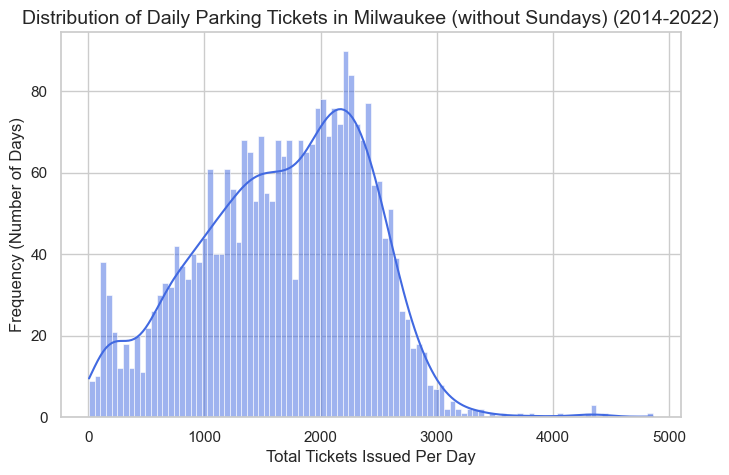

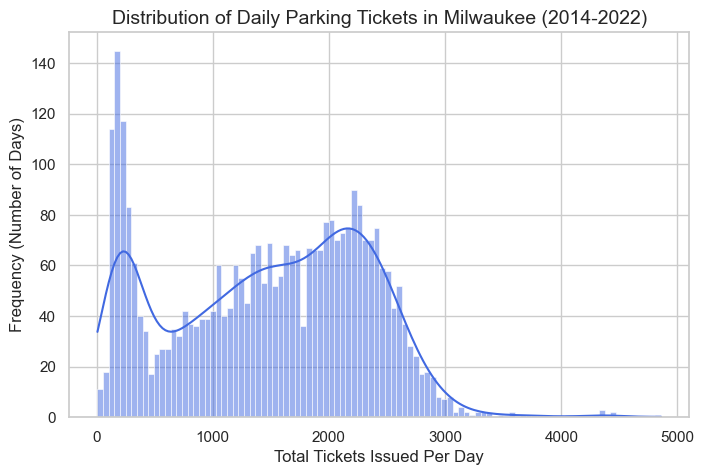

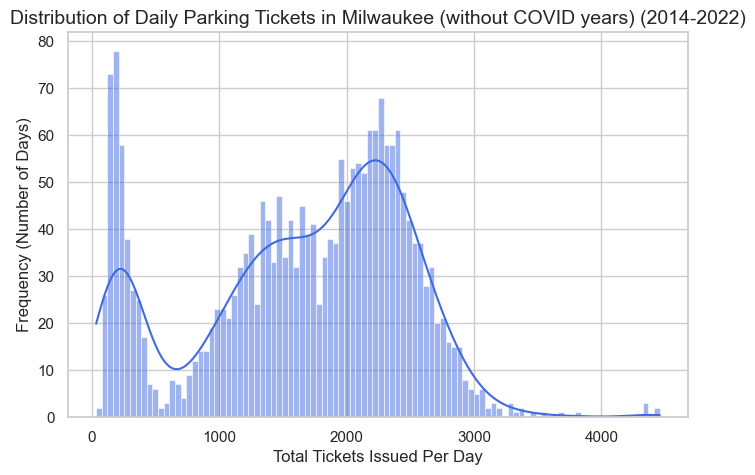

In [52]:
sns.set_theme(style="whitegrid")

# drop the year 2020 and 2021 for the histogram to see if the distribution changes without the covid years (since they are likely outliers in terms of ticket counts)
daily_summary_no_covid_df = daily_summary_df[~daily_summary_df['Year'].isin([2020, 2021, 2022])]
daily_summary_no_sunday_df = daily_summary_df[~daily_summary_df['WeekDay'].isin(['Sunday'])]

# Histogram Plot of the Distribution of Total Daily Tickets to show Right Skewed Tail
plt.figure(figsize=(8, 5))
sns.histplot(daily_summary_no_sunday_df['total_tickets'], bins=100, kde=True, color='royalblue')


plt.title("Distribution of Daily Parking Tickets in Milwaukee (without Sundays) (2014-2022)", fontsize=14)
plt.xlabel("Total Tickets Issued Per Day", fontsize=12)
plt.ylabel("Frequency (Number of Days)", fontsize=12)
plt.show()

# plot with sundays included as well to see the difference
plt.figure(figsize=(8, 5))
sns.histplot(daily_summary_df['total_tickets'], bins=100, kde=True, color='royalblue')
plt.title("Distribution of Daily Parking Tickets in Milwaukee (2014-2022)", fontsize=14)
plt.xlabel("Total Tickets Issued Per Day", fontsize=12)
plt.ylabel("Frequency (Number of Days)", fontsize=12)
plt.show()

# plot without covid years
plt.figure(figsize=(8, 5))
sns.histplot(daily_summary_no_covid_df['total_tickets'], bins=100, kde=True, color='royalblue')
plt.title("Distribution of Daily Parking Tickets in Milwaukee (without COVID years) (2014-2022)", fontsize=14)
plt.xlabel("Total Tickets Issued Per Day", fontsize=12)
plt.ylabel("Frequency (Number of Days)", fontsize=12)
plt.show()


Temporal (Time) Features

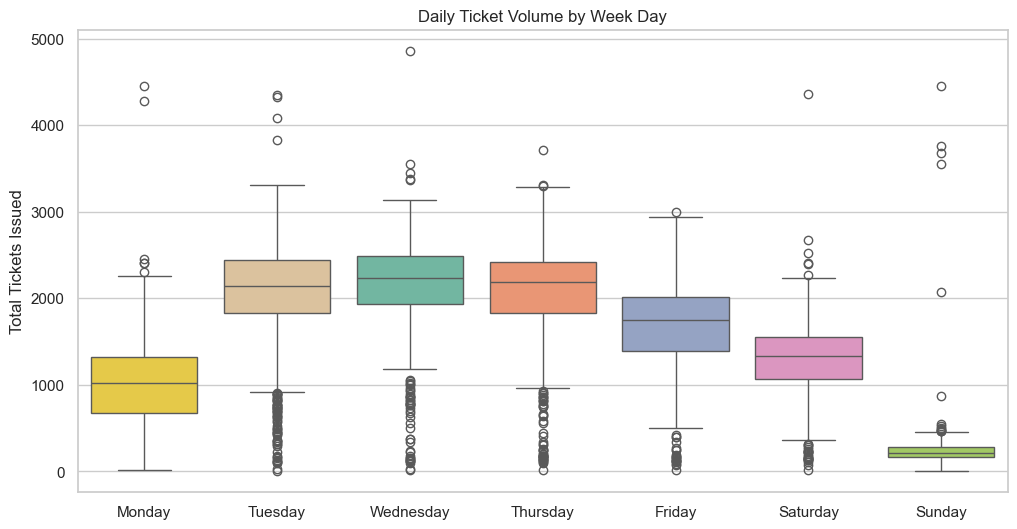

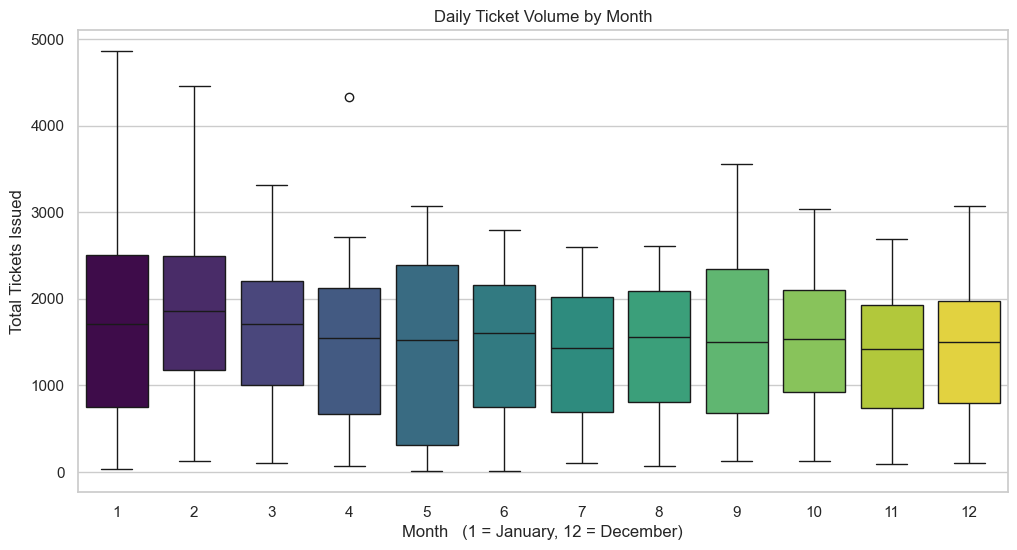

In [53]:
# WeekDay	Year	Month	Day	 is_weekend	is_holiday  
temporal_cols = ['WeekDay', 'Year', 'Month', 'Day', 'is_weekend', 'is_holiday']

# WeekDay vs. Total_Tickets (Daily Count) -> Cat. vs. Num - Boxplot
days_ordered = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12, 6))
sns.boxplot(x='WeekDay', y='total_tickets', order=days_ordered, data=daily_summary_df, hue='WeekDay', palette='Set2')
plt.title("Daily Ticket Volume by Week Day")
plt.xlabel("")
plt.ylabel("Total Tickets Issued")
plt.show()

# Month vs. Total_Tickets
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='total_tickets',  data=daily_summary_df, hue='Month', palette='viridis', legend=False)
plt.title("Daily Ticket Volume by Month")
plt.xlabel("Month   (1 = January, 12 = December)")
plt.ylabel("Total Tickets Issued")
plt.show()


Sunday is very CLEARLY the least Ticketed day, followed by Monday!

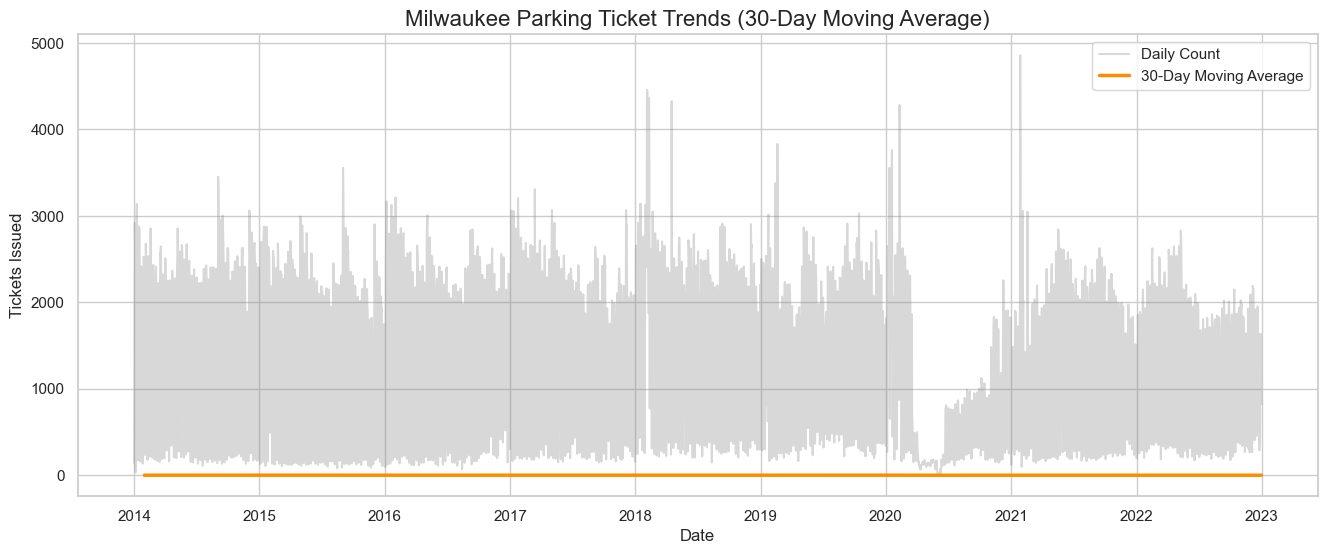

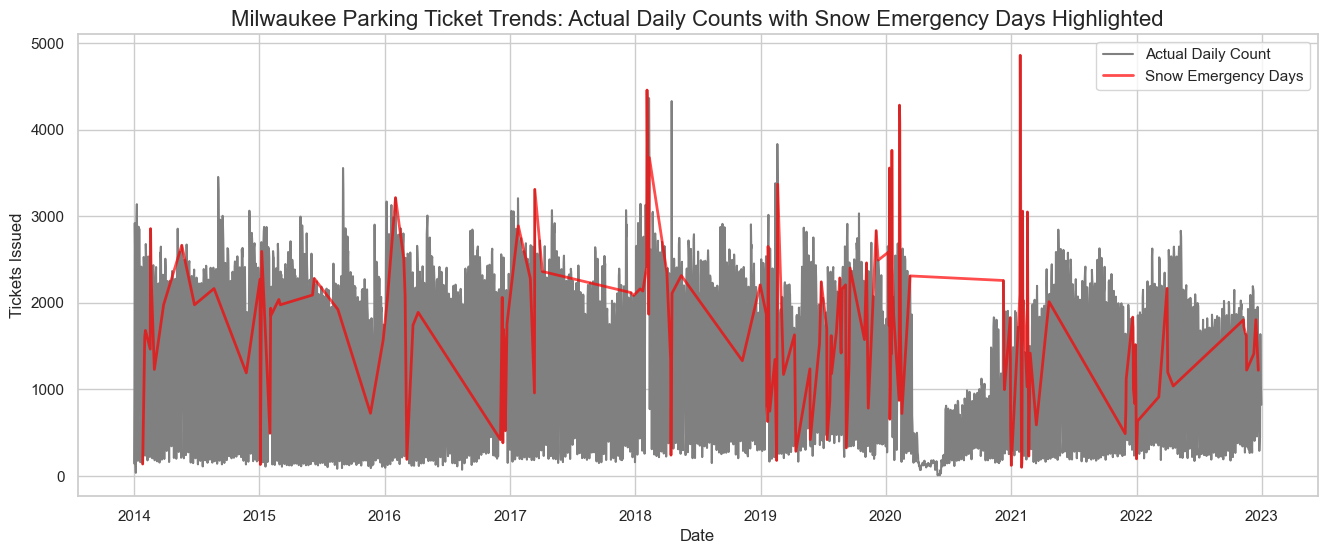

In [54]:
# Dataframe is sorted chronologically
daily_summary_df = daily_summary_df.sort_values('join_date').reset_index(drop=True)

# Calculate the 30-day moving average  [a single day's ticket total and 29 days prior to that Averaged]
daily_summary_df['rolling_30d_avg'] = daily_summary_df['total_tickets'].rolling(window=30).mean().shift(1)  # Shift by 1 to avoid look-ahead bias

# normalize it
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
numerical_features = ['rolling_30d_avg']
daily_summary_df[numerical_features] = scaler.fit_transform(daily_summary_df[numerical_features])


plt.figure(figsize=(16, 6))
# Plot the noisy daily data lightly in the background
sns.lineplot(data=daily_summary_df, x='join_date', y='total_tickets', color='gray', alpha=0.3, label='Daily Count')

# Plot the smoothed 30-day average boldly on top
sns.lineplot(data=daily_summary_df, x='join_date', y='rolling_30d_avg', color='darkorange', linewidth=2.5, label='30-Day Moving Average')

plt.title("Milwaukee Parking Ticket Trends (30-Day Moving Average)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Tickets Issued")
plt.legend()
plt.show()

# now we just filter to only see the snow emergency days to see if those are the spikes we see
snow_emergency_days_df = daily_summary_df[daily_summary_df['is_snow_emergency'] == 1]
plt.figure(figsize=(16, 6))
sns.lineplot(data=daily_summary_df, x='join_date', y='total_tickets', color='gray', label='Actual Daily Count')
sns.lineplot(data=snow_emergency_days_df, x='join_date', y='total_tickets', color='red', alpha=0.7, linewidth=2, label='Snow Emergency Days')
plt.title("Milwaukee Parking Ticket Trends: Actual Daily Counts with Snow Emergency Days Highlighted", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Tickets Issued")
plt.legend()
plt.show()

In [55]:
# Statistical Testing -- Temporal Features
from scipy.stats import kruskal

print("--- STATISTICAL TESTING: TEMPORAL FEATURES ---")
results = {}

# 1. WeekDay (multi-categorical) vs. Total Tickets [Target] (numerical) -> Kruskal-Wallis test (Bucket of tickets for each weekday)
day_groups = [daily_summary_df[daily_summary_df['WeekDay'] == day]['total_tickets'] for day in days_ordered]
stat, p_val = kruskal(*day_groups)
results["WeekDay_vs_tickets"] = (stat, p_val)

# 2. Month (categorical) vs. Total Tickets (numerical) -> Kruskal-Wallis test
month_groups = [daily_summary_df[daily_summary_df['Month'] == month]['total_tickets'] for month in range(1, 13)]
stat, p_val = kruskal(*month_groups)
results["Month_vs_tickets"] = (stat, p_val)

# 3. Year (categorical) vs. Total Tickets (numerical)
year_groups = [daily_summary_df[daily_summary_df['Year'] == year]['total_tickets'] for year in daily_summary_df['Year'].unique()]
stat, p_val = kruskal(*year_groups)
results["Year_vs_tickets"] = (stat, p_val)

# 4. Day vs. Total Tickets -> Kruskal-Wallis test
day_number_groups = [daily_summary_df[daily_summary_df['Day'] == day]['total_tickets'] for day in range(1, 32)]
stat, p_val = kruskal(*day_number_groups)
results["Day_vs_tickets"] = (stat, p_val)

# print results
for test, (stat, p_val) in results.items():
    print(f"{test}: Kruskal-Wallis H-statistic = {stat:.3f}, p-value = {p_val:.3g}")

from scipy.stats import mannwhitneyu  # binary categorical vs. numerical
binary_results = {}

# 5. is_weekend (binary categorical - 2 groups) vs. Total Tickets (numerical) -> Mann-Whitney U test
weekend_tickets = daily_summary_df[daily_summary_df['is_weekend'] == 1]['total_tickets']
weekday_tickets = daily_summary_df[daily_summary_df['is_weekend'] == 0]['total_tickets']
stat, p_val = mannwhitneyu(weekend_tickets, weekday_tickets)
binary_results["is_weekend_vs_tickets"] = (stat, p_val)

# 6. is_holiday (binary categorical - 2 groups) vs. Total Tickets (numerical) -> Mann-Whitney U test
holiday_tickets = daily_summary_df[daily_summary_df['is_holiday'] == 1]['total_tickets']
not_holiday_tickets = daily_summary_df[daily_summary_df['is_holiday'] == 0]['total_tickets']
stat, p_val = mannwhitneyu(holiday_tickets, not_holiday_tickets)
binary_results["is_holiday_vs_tickets"] = (stat, p_val)

# is_sunday vs. Total Tickets
sunday_tickets = daily_summary_df[daily_summary_df['is_sunday'] == 1]['total_tickets']
not_sunday_tickets = daily_summary_df[daily_summary_df['is_sunday'] == 0]['total_tickets']
stat, p_val = mannwhitneyu(sunday_tickets, not_sunday_tickets)
binary_results["is_sunday_vs_tickets"] = (stat, p_val)

# print results

for test, (stat, p_val) in binary_results.items():
    print(f"{test}: Mann-Whitney statistic = {stat:.3f}, p-value = {p_val:.3g}")

--- STATISTICAL TESTING: TEMPORAL FEATURES ---
WeekDay_vs_tickets: Kruskal-Wallis H-statistic = 1838.493, p-value = 0
Month_vs_tickets: Kruskal-Wallis H-statistic = 61.101, p-value = 5.78e-09
Year_vs_tickets: Kruskal-Wallis H-statistic = 387.142, p-value = 1.05e-78
Day_vs_tickets: Kruskal-Wallis H-statistic = 21.845, p-value = 0.86
is_weekend_vs_tickets: Mann-Whitney statistic = 348076.500, p-value = 7.82e-207
is_holiday_vs_tickets: Mann-Whitney statistic = 129111.000, p-value = 8.79e-21
is_sunday_vs_tickets: Mann-Whitney statistic = 55542.500, p-value = 5.18e-222


Violation Sub-Count Features

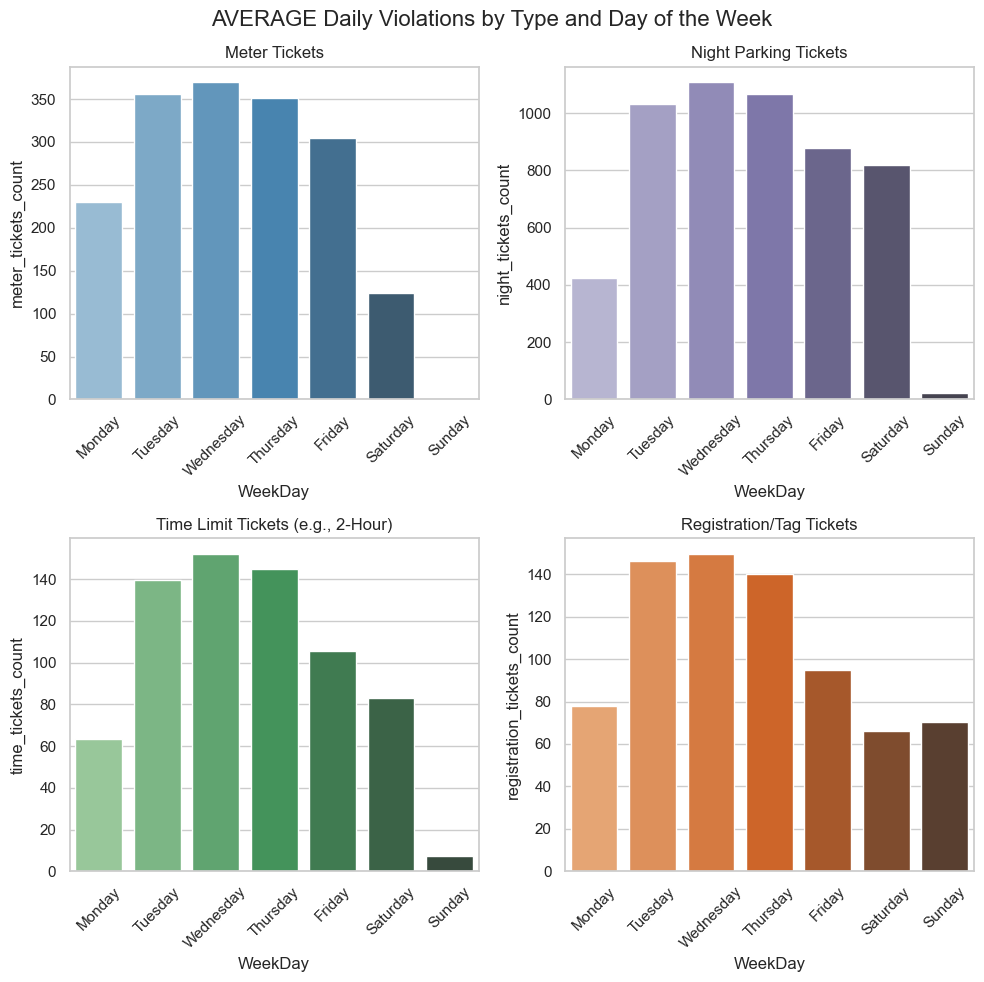

In [56]:
# Group by weekday and calculate the mean (single average number for each day)  for each sub-count
sub_counts = ['meter_tickets_count', 'night_tickets_count', 'time_tickets_count', 'registration_tickets_count']
sub_counts_grouped = daily_summary_df.groupby('WeekDay')[sub_counts].mean().reindex(days_ordered).reset_index()

# Set up the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('AVERAGE Daily Violations by Type and Day of the Week', fontsize=16)

# 1. Meter Tickets
sns.barplot(ax=axes[0, 0], data=sub_counts_grouped, x='WeekDay', y='meter_tickets_count', hue='WeekDay', palette='Blues_d')
axes[0, 0].set_title('Meter Tickets')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Night Tickets
sns.barplot(ax=axes[0, 1], data=sub_counts_grouped, x='WeekDay', y='night_tickets_count', hue='WeekDay', palette='Purples_d')
axes[0, 1].set_title('Night Parking Tickets')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Time Limit Tickets
sns.barplot(ax=axes[1, 0], data=sub_counts_grouped, x='WeekDay', y='time_tickets_count', hue='WeekDay', palette='Greens_d')
axes[1, 0].set_title('Time Limit Tickets (e.g., 2-Hour)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Registration Tickets
sns.barplot(ax=axes[1, 1], data=sub_counts_grouped, x='WeekDay', y='registration_tickets_count', hue='WeekDay', palette='Oranges_d')
axes[1, 1].set_title('Registration/Tag Tickets')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [57]:
# Statistical Testing -- Violation subcount Features
# Testing to see if the (Temporal) Day of the Week significantly impacts the volume of these specific ticket violations
from scipy.stats import kruskal

print("--- STATISTICAL TESTING: Temporal Violation Sub-counts [min-targets] by Weekday ---")
results = {}

# meter_tickets_count, night_tickets_count, registration_tickets_count, time_tickets_count
for sub_count_col in sub_counts:
    groups = [daily_summary_df[daily_summary_df['WeekDay'] == day][sub_count_col] for day in days_ordered]
    stat, p_val = kruskal(*groups)
    
    print(f"{sub_count_col}_vs_WeekDay: Kruskal-Wallis H-statistic = {stat:.3f}, p-value = {p_val:.3g}")

--- STATISTICAL TESTING: Temporal Violation Sub-counts [min-targets] by Weekday ---
meter_tickets_count_vs_WeekDay: Kruskal-Wallis H-statistic = 1770.370, p-value = 0
night_tickets_count_vs_WeekDay: Kruskal-Wallis H-statistic = 1547.731, p-value = 0
time_tickets_count_vs_WeekDay: Kruskal-Wallis H-statistic = 1421.070, p-value = 6.64e-304
registration_tickets_count_vs_WeekDay: Kruskal-Wallis H-statistic = 886.000, p-value = 3.99e-188


Weather Features

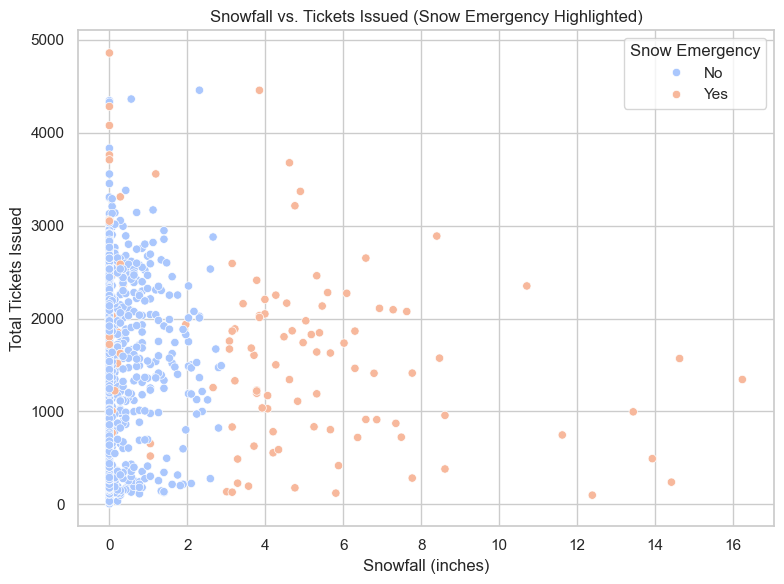

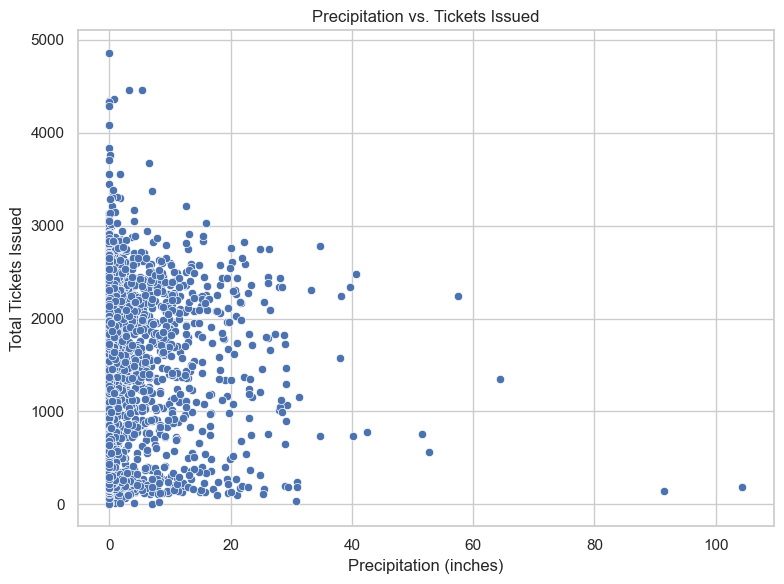

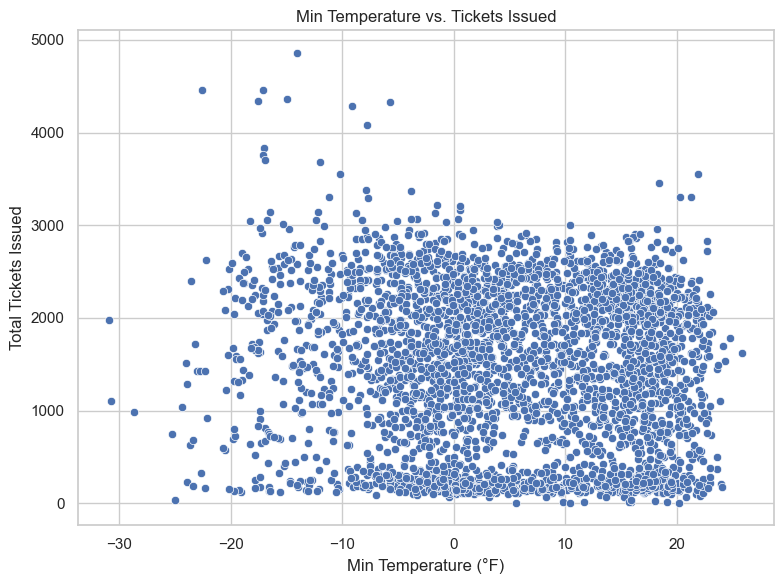

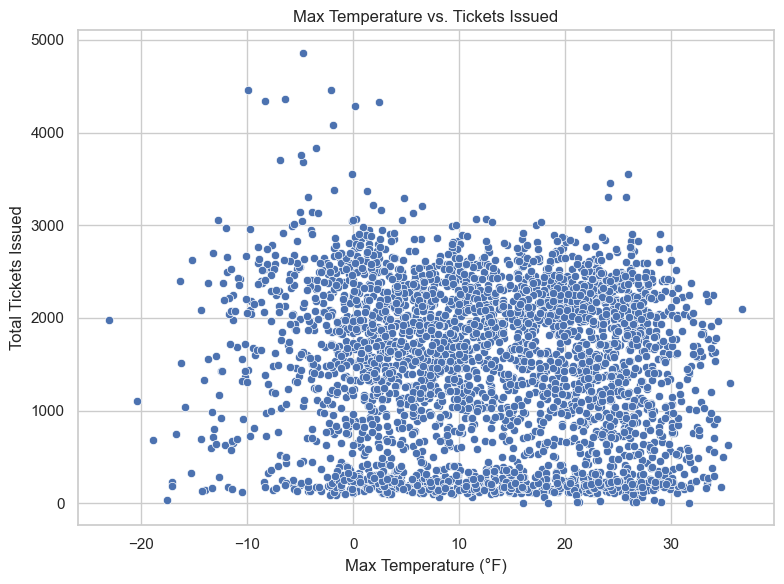

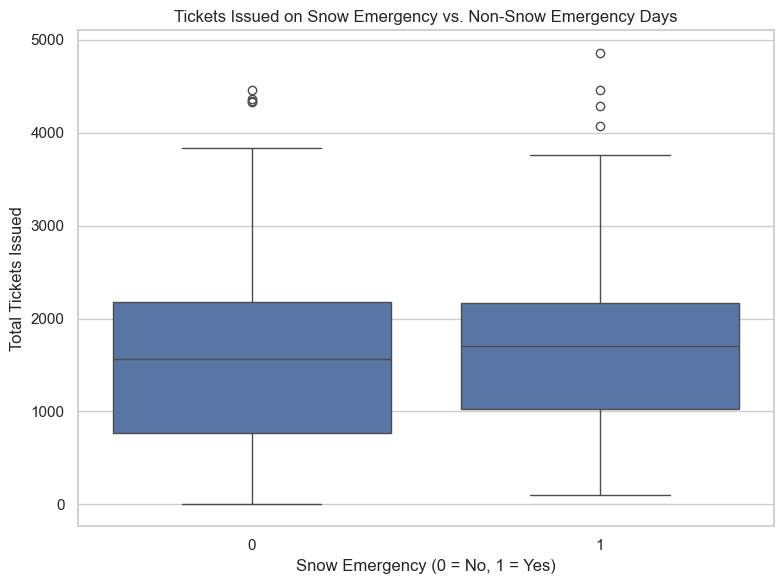

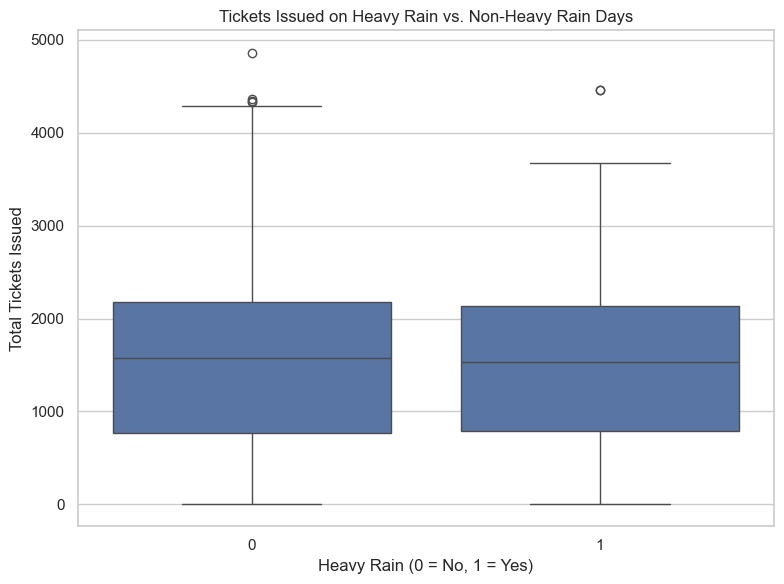

In [58]:
# Weather and tickets issued: separate plots
import matplotlib.pyplot as plt
import seaborn as sns

daily_summary_df = daily_summary_df.copy()
daily_summary_df["snow_emergency_label"] = daily_summary_df["is_snow_emergency"].map({0: "No", 1: "Yes"})

# snowfall vs. tickets issued colored by snow emergency
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=daily_summary_df,
    x="snowfall",
    y="total_tickets",
    hue="snow_emergency_label",
    palette="coolwarm"
)
plt.title("Snowfall vs. Tickets Issued (Snow Emergency Highlighted)")
plt.xlabel("Snowfall (inches)")
plt.ylabel("Total Tickets Issued")
plt.legend(title="Snow Emergency")
plt.tight_layout()
plt.show()

# precipitation vs. tickets issued
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=daily_summary_df,
    x="precipitation",
    y="total_tickets"
)
plt.title("Precipitation vs. Tickets Issued")
plt.xlabel("Precipitation (inches)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

# Min temp vs. tickets issued
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=daily_summary_df,
    x="min_temp",
    y="total_tickets"
)
plt.title("Min Temperature vs. Tickets Issued")
plt.xlabel("Min Temperature (°F)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

# Max temp vs. tickets issued
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=daily_summary_df,
    x="max_temp",
    y="total_tickets"
)
plt.title("Max Temperature vs. Tickets Issued")
plt.xlabel("Max Temperature (°F)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

# is_snow_emergency vs. tickets issued
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=daily_summary_df,
    x="is_snow_emergency",
    y="total_tickets"
)
plt.title("Tickets Issued on Snow Emergency vs. Non-Snow Emergency Days")
plt.xlabel("Snow Emergency (0 = No, 1 = Yes)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

# is_heavy_rain vs. tickets issued
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=daily_summary_df,
    x="is_heavy_rain",
    y="total_tickets"
)
plt.title("Tickets Issued on Heavy Rain vs. Non-Heavy Rain Days")
plt.xlabel("Heavy Rain (0 = No, 1 = Yes)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

In [59]:
# spearman correlations
from scipy.stats import spearmanr

results = {}

# snowfall vs. tickets
corr, pval = spearmanr(daily_summary_df["snowfall"], daily_summary_df["total_tickets"])
results["snowfall_vs_tickets"] = (corr, pval)

# precipitation vs. tickets
corr, pval = spearmanr(daily_summary_df["precipitation"], daily_summary_df["total_tickets"])
results["precipitation_vs_tickets"] = (corr, pval)

# min temp vs. tickets
corr, pval = spearmanr(daily_summary_df["min_temp"], daily_summary_df["total_tickets"])
results["min_temp_vs_tickets"] = (corr, pval)

# max temp vs. tickets
corr, pval = spearmanr(daily_summary_df["max_temp"], daily_summary_df["total_tickets"])
results["max_temp_vs_tickets"] = (corr, pval)

for test, (corr, pval) in results.items():
    print(f"{test}: Spearman correlation = {corr:.3f}, p-value = {pval:.3g}")

    
# chi-squared test for is_snow_emergency vs. total_tickets (categorize total_tickets into bins for chi-squared)
from scipy.stats import chi2_contingency

# create contingency table for is_snow_emergency and binned total_tickets
daily_summary_df["tickets_bin"] = pd.cut(daily_summary_df["total_tickets"], bins=5)
contingency_table = pd.crosstab(daily_summary_df["is_snow_emergency"], daily_summary_df["tickets_bin"])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared test for Snow Emergency vs. Total Tickets (binned): chi2 = {chi2:.3f}, p-value = {p:.3g}")

# chi-squared test for is_heavy_rain vs. total_tickets (categorize total_tickets into bins for chi-squared)
# create contingency table for is_heavy_rain and binned total_tickets
contingency_table = pd.crosstab(daily_summary_df["is_heavy_rain"], daily_summary_df["tickets_bin"])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared test for Heavy Rain vs. Total Tickets (binned): chi2 = {chi2:.3f}, p-value = {p:.3g}")

# chi-squared test for is_snow_emergency_lag1 vs. total_tickets (categorize total_tickets into bins for chi-squared)
# create contingency table for is_snow_emergency_lag1 and binned total_tickets
contingency_table = pd.crosstab(daily_summary_df["is_snow_emergency_lag1"], daily_summary_df["tickets_bin"])
chi2, p, _, _ = chi2_contingency(contingency_table)
print(f"Chi-squared test for Snow Emergency (Lag 1) vs. Total Tickets (binned): chi2 = {chi2:.3f}, p-value = {p:.3g}")

# chi-squared test for is_snow_emergency_lag2 vs. total_tickets (categorize total_tickets into bins for chi-squared)
# create contingency table for is_snow_emergency_lag2 and binned total_tickets
contingency_table = pd.crosstab(daily_summary_df["is_snow_emergency_lag2"], daily_summary_df["tickets_bin"])
chi2, p, _, _ = chi2_contingency(contingency_table)
print(f"Chi-squared test for Snow Emergency (Lag 2) vs. Total Tickets (binned): chi2 = {chi2:.3f}, p-value = {p:.3g}")

snowfall_vs_tickets: Spearman correlation = 0.015, p-value = 0.401
precipitation_vs_tickets: Spearman correlation = -0.009, p-value = 0.625
min_temp_vs_tickets: Spearman correlation = -0.066, p-value = 0.000159
max_temp_vs_tickets: Spearman correlation = -0.093, p-value = 8.39e-08
Chi-squared test for Snow Emergency vs. Total Tickets (binned): chi2 = 62.235, p-value = 9.83e-13
Chi-squared test for Heavy Rain vs. Total Tickets (binned): chi2 = 2.223, p-value = 0.695
Chi-squared test for Snow Emergency (Lag 1) vs. Total Tickets (binned): chi2 = 112.176, p-value = 2.5e-23
Chi-squared test for Snow Emergency (Lag 2) vs. Total Tickets (binned): chi2 = 48.538, p-value = 7.29e-10


### co-linearity testing

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd

# one-hot encode WeekDay (drop_first to avoid dummy variable trap)
X = daily_summary_df.copy()
X = pd.get_dummies(X, columns=['WeekDay'], drop_first=True)

# select only the actual potential columns for VIF
vif_features = [
    'rolling_30d_avg',
    'is_snow_emergency_lag1',
    'is_snow_emergency_lag2',
    'Month',
    'is_holiday',
    'is_weekend'
    # plus all one-hot WeekDay columns automatically added
] + [col for col in X.columns if col.startswith('WeekDay_')]

# drop rows with missing values in these columns
X_vif = X[vif_features].dropna()
# convert all columns to float
X_vif = X_vif.astype(float)

X_vif.info()

<class 'pandas.DataFrame'>
RangeIndex: 3257 entries, 30 to 3286
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   rolling_30d_avg         3257 non-null   float64
 1   is_snow_emergency_lag1  3257 non-null   float64
 2   is_snow_emergency_lag2  3257 non-null   float64
 3   Month                   3257 non-null   float64
 4   is_holiday              3257 non-null   float64
 5   is_weekend              3257 non-null   float64
 6   WeekDay_num             3257 non-null   float64
 7   WeekDay_Monday          3257 non-null   float64
 8   WeekDay_Saturday        3257 non-null   float64
 9   WeekDay_Sunday          3257 non-null   float64
 10  WeekDay_Thursday        3257 non-null   float64
 11  WeekDay_Tuesday         3257 non-null   float64
 12  WeekDay_Wednesday       3257 non-null   float64
dtypes: float64(13)
memory usage: 330.9 KB


In [61]:
# calculate VIF for each feature
vif_df = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_df)

                   feature        VIF
0          rolling_30d_avg   1.042547
1   is_snow_emergency_lag1   1.074930
2   is_snow_emergency_lag2   1.076911
3                    Month   1.044046
4               is_holiday   1.020558
5               is_weekend        inf
6              WeekDay_num  23.524609
7           WeekDay_Monday   3.862594
8         WeekDay_Saturday        inf
9           WeekDay_Sunday        inf
10        WeekDay_Thursday   1.759013
11         WeekDay_Tuesday   2.598177
12       WeekDay_Wednesday   1.975596


c:\Users\eckbergj\.vscode\Milwaukee-Ticket-Data-Analysis\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


### Modeling

In [71]:
# loop for Negative Binomial regression with rolling window cross-validation
import numpy as np
import pandas as pd
from statsmodels.discrete.discrete_model import NegativeBinomial
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

# features to use
features = [
    'is_holiday', 'is_sunday',
    'is_snow_emergency_lag1',
    'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos'
    ]
# with one hot encoded WeekDay & month
# get dummy variables for WeekDay and Month (drop_first to avoid dummy variable trap)
# daily_summary_df = pd.get_dummies(daily_summary_df, columns=['WeekDay'], drop_first=True)
# daily_summary_df = pd.get_dummies(daily_summary_df, columns=['Month'], drop_first=True)
# features = [
#     'is_holiday', 'is_weekend',
#     'is_snow_emergency_lag1', 'is_snow_emergency_lag2',
#     'rolling_30d_avg', 'WeekDay_Friday', 'WeekDay_Monday', 
#     'WeekDay_Saturday', 'WeekDay_Sunday', 'WeekDay_Thursday', 'WeekDay_Tuesday', 'WeekDay_Wednesday']
target = 'total_tickets'

# drop 2020 (COVID-19 pandemic year) to avoid instability due to abnormal enforcement patterns?
model_df = daily_summary_df[daily_summary_df['Year'] != 2020].dropna(subset=features + [target]).copy()

# rolling window cross-validation
n_splits = 8
window_size = int(len(model_df) / (n_splits + 1))

pearson_stats = []
deviance_stats = []
nmse_scores = []  # normalized MSE
loss_values = []  # final loss function value for each window

# prepare a column for predictions (initialize with NaN)
daily_summary_df['predicted_tickets'] = np.nan

for i in range(n_splits):
    train_start = i * window_size
    train_end = train_start + window_size
    test_start = train_end
    test_end = test_start + window_size
    
    train = model_df.iloc[train_start:train_end]
    test = model_df.iloc[test_start:test_end]
    
    if len(test) == 0:
        break
    
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]
    
    # Add intercept
    import statsmodels.api as sm
    X_train_const = sm.add_constant(X_train)
    X_test_const = sm.add_constant(X_test)
    
    # fit Negative Binomial model (with intercept)
    model = NegativeBinomial(y_train, X_train_const)
    result = model.fit(disp=0)
    y_pred = result.predict(X_test_const)
    
    # save the final loss function value (negative log-likelihood)
    loss_values.append(result.llf)
    
    # debugging print if y_pred has nans
    # The predicted_tickets column is NaN for the first year because of how rolling window cross-validation is set up

    if np.isnan(y_pred).any():
        print(f"Warning: NaNs detected in y_pred for fold {i+1}. Indices: {np.where(np.isnan(y_pred))[0]}")
    
    # remove any rows where y_test or y_pred is NaN
    valid_idx = ~(np.isnan(y_test) | np.isnan(y_pred))
    y_test_valid = y_test[valid_idx]
    y_pred_valid = y_pred[valid_idx]
    if len(y_test_valid) == 0:
        print(f"All predictions or targets are NaN for fold {i+1}, skipping this fold.")
        continue  # skip this fold if all values are NaN
    
    # pearson statistic
    mu = y_pred_valid
    alpha = result.params.get('alpha', result.scale)  # fallback if alpha not in params
    var = mu + alpha * mu**2
    pearson = np.sum((y_test_valid - mu) ** 2 / var)
    pearson_stats.append(pearson / len(y_test_valid))
    
    # deviance statistic (Negative Binomial deviance)
    y = y_test_valid.values
    mu = mu.values if hasattr(mu, 'values') else mu
    eps = 1e-10  # avoid log(0)
    deviance = 2 * np.sum(
    y * np.log((y + eps) / (mu + eps)) - (y + 1/alpha) * np.log((1 + alpha * y + eps) / (1 + alpha * mu + eps))
    )
    deviance_stats.append(deviance / len(y_test_valid))
    
    # Normalized MSE (NMSE)
    mse = mean_squared_error(y_test_valid, y_pred_valid)
    nmse = mse / np.mean(y_test_valid ** 2)
    nmse_scores.append(nmse)

    # pearsons r as a sanity check?
    
    # write predictions into the original dataframe for the test period
    # update predicted_tickets for the test dates
    test_dates = test['join_date']
    daily_summary_df.loc[daily_summary_df['join_date'].isin(test_dates), 'predicted_tickets'] = y_pred.values

print(f"Rolling window Negative Binomial regression results (n_splits={n_splits}):")
for i, (p, d, nmse, loss) in enumerate(zip(pearson_stats, deviance_stats, nmse_scores, loss_values), 1):
    print(f"Fold {i}: Pearson/df = {p:.2f}, Deviance/df = {d:.2f}, NMSE = {nmse:.4f}, Final Log-Likelihood = {loss:.2f}")

# now take 2022-2023 as the held out test set and fit the model on all prior data to see how it performs on the most recent data
# still drop covid year 2020 from training to avoid instability
train_final = model_df[model_df['Year'] < 2022]
test_final = daily_summary_df[daily_summary_df['Year'] >= 2022].copy()
X_train_final = train_final[features]
y_train_final = train_final[target]
X_test_final = test_final[features]
y_test_final = test_final[target]
# Add intercept
X_train_final_const = sm.add_constant(X_train_final)
X_test_final_const = sm.add_constant(X_test_final)
# fit final model
final_model = NegativeBinomial(y_train_final, X_train_final_const)
final_result = final_model.fit(disp=0)
y_pred_final = final_result.predict(X_test_final_const)
# evaluate final model on held-out test set
final_loss = final_result.llf
alpha = final_result.params.get('alpha', 0.1) # Default to 0.1 or similar if not found
eps = 1e-10
# final Pearson
mu_final = y_pred_final
var_final = mu_final + alpha * mu_final**2
final_pearson = np.sum((y_test_final - mu_final) ** 2 / var_final) / len(y_test_final)
term1 = y_test_final * np.log((y_test_final + eps) / (mu_final + eps))
term2 = (y_test_final + 1/alpha) * np.log((1 + alpha * y_test_final + eps) / (1 + alpha * mu_final + eps))
final_deviance = 2 * np.sum(term1 - term2) / len(y_test_final)
final_nmse = mean_squared_error(y_test_final, y_pred_final) / np.mean(y_test_final ** 2)
print(f"Final model performance on held-out test set (2022-2023): Pearson/df = {final_pearson:.2f}, Deviance/df = {final_deviance:.2f}, NMSE = {final_nmse:.4f}, Log-Likelihood = {final_loss:.2f}")

# Predict on the entire dataset to visualize the full fit timeline
X_all_nb = sm.add_constant(daily_summary_df[features])
daily_summary_df['full_nb_predicted_tickets'] = final_result.predict(X_all_nb)
# Set COVID years to NaN to exclude from plots
daily_summary_df.loc[daily_summary_df['Year'].isin([2020]), 'full_nb_predicted_tickets'] = np.nan
                                                                                                                                                              


Rolling window Negative Binomial regression results (n_splits=8):
Fold 1: Pearson/df = 0.76, Deviance/df = 1.12, NMSE = 0.0409, Final Log-Likelihood = -2404.13
Fold 2: Pearson/df = 0.86, Deviance/df = 1.30, NMSE = 0.0450, Final Log-Likelihood = -2375.91
Fold 3: Pearson/df = 1.75, Deviance/df = 1.28, NMSE = 0.0416, Final Log-Likelihood = -2385.70
Fold 4: Pearson/df = 15.37, Deviance/df = 2.95, NMSE = 0.0972, Final Log-Likelihood = -2386.53
Fold 5: Pearson/df = 0.98, Deviance/df = 1.11, NMSE = 0.1514, Final Log-Likelihood = -2491.22
Fold 6: Pearson/df = 0.83, Deviance/df = 1.38, NMSE = 0.0989, Final Log-Likelihood = -2432.86
Fold 7: Pearson/df = 0.78, Deviance/df = 1.10, NMSE = 0.0760, Final Log-Likelihood = -2422.45
Fold 8: Pearson/df = 0.95, Deviance/df = 1.12, NMSE = 0.0801, Final Log-Likelihood = -2355.45
Final model performance on held-out test set (2022-2023): Pearson/df = 0.74, Deviance/df = 1.23, NMSE = 0.1346, Log-Likelihood = -19373.30


In [63]:
# model.summary()
# model_df.head()
daily_summary_df = daily_summary_df.sort_values('join_date').reset_index(drop=True)

In [72]:
# Build Poisson Regression Model (as a baseline to Negative Binomial) with the same features and rolling window cross-validation
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

print("--- POISSON REGRESSION (BASELINE COMPARISON) ---")

# Using  exact same feature set and target

# Drop 2020 
model_df = daily_summary_df[daily_summary_df['Year'] != 2020].dropna(subset=features + [target]).copy()

n_splits = 7
window_size = int(len(model_df) / (n_splits + 1))

poisson_pearson_stats = []  # Pearson goodness-of-fit statistic (not r)
poisson_deviance_stats = []
poisson_nmse_scores = []
poisson_loss_values = []
poisson_r_scores = []  # Pearson correlation coefficient (r)

# Make a column for POISSON predictions
daily_summary_df['poisson_predicted_tickets'] = np.nan

for i in range(n_splits):
    train_start = i * window_size
    train_end = train_start + window_size
    test_start = train_end
    test_end = test_start + window_size
    
    train = model_df.iloc[train_start:train_end]
    test = model_df.iloc[test_start:test_end]
    
    if len(test) == 0:
        break
    
    X_train_const = sm.add_constant(train[features])
    y_train = train[target]
    X_test_const = sm.add_constant(test[features])
    y_test = test[target]
    
    # Fit the standard Poisson GLM
    poisson_model = sm.GLM(y_train, X_train_const, family=sm.families.Poisson())
    result = poisson_model.fit()
    y_pred = result.predict(X_test_const)
    
    poisson_loss_values.append(result.llf)
    
    valid_idx = ~(np.isnan(y_test) | np.isnan(y_pred))
    y_test_valid, y_pred_valid = y_test[valid_idx], y_pred[valid_idx]
    
    if len(y_test_valid) == 0: 
        continue
    
    # Calculate stats using statsmodels built-in properties for GLM
    # Divide by degrees of freedom to match  Pearson/df output
    df_resid = len(y_test_valid) - X_test_const.shape[1]
    
    # For out-of-sample deviance/pearson, calculate manually:
    mu = y_pred_valid
    y = y_test_valid
    
    # Poisson Pearson: Sum( (y - mu)^2 / mu )
    pearson = np.sum((y - mu)**2 / mu)
    poisson_pearson_stats.append(pearson / df_resid)
    
    # Poisson Deviance: 2 * Sum( y * log(y/mu) - (y - mu) )
    eps = 1e-10
    deviance = 2 * np.sum(y * np.log((y + eps) / (mu + eps)) - (y - mu))
    poisson_deviance_stats.append(deviance / df_resid)
    
    # NMSE
    mse = mean_squared_error(y_test_valid, y_pred_valid)
    poisson_nmse_scores.append(mse / np.mean(y_test_valid ** 2))
    
    # Pearson correlation coefficient (r) between actual and predicted
    from scipy.stats import pearsonr
    r, r_p = pearsonr(y_test_valid, y_pred_valid)
    poisson_r_scores.append(r)
    
    # Save predictions
    test_dates = test['join_date']
    daily_summary_df.loc[daily_summary_df['join_date'].isin(test_dates), 'poisson_predicted_tickets'] = y_pred.values

print(f"Rolling window POISSON regression results (n_splits={n_splits}):")
for i, (p, d, nmse, loss, r) in enumerate(zip(poisson_pearson_stats, poisson_deviance_stats, poisson_nmse_scores, poisson_loss_values, poisson_r_scores), 1):
    print(f"Fold {i}: Pearson/df = {p:.2f}, Deviance/df = {d:.2f}, NMSE = {nmse:.4f}, Final Log-Likelihood = {loss:.2f}, Pearson r = {r:.3f}")

# Fit final Poisson model on all data prior to 2022 and evaluate on 2022-2023 held-out test set
train_final = model_df[model_df['Year'] < 2022]
test_final = daily_summary_df[daily_summary_df['Year'] >= 2022].copy()
X_train_final_const = sm.add_constant(train_final[features])
y_train_final = train_final[target]
X_test_final_const = sm.add_constant(test_final[features])
y_test_final = test_final[target]
poisson_final_model = sm.GLM(y_train_final, X_train_final_const, family=sm.families.Poisson())
poisson_final_result = poisson_final_model.fit()
y_pred_final = poisson_final_result.predict(X_test_final_const)
final_loss = poisson_final_result.llf
df_resid = len(y_test_final) - X_test_final_const.shape[1]
mu = y_pred_final
y = y_test_final
final_pearson = np.sum((y - mu)**2 / mu) / df_resid
eps = 1e-10
final_deviance = 2 * np.sum(y * np.log((y + eps) / (mu + eps)) - (y - mu)) / df_resid
final_nmse = mean_squared_error(y_test_final, y_pred_final) / np.mean(y_test_final ** 2)
final_r, _ = pearsonr(y_test_final, y_pred_final)
print(f"Final POISSON model performance on held-out test set (2022-2023): Pearson/df = {final_pearson:.2f}, Deviance/df = {final_deviance:.2f}, NMSE = {final_nmse:.4f}, Pearson r = {final_r:.3f}, Log-Likelihood = {final_loss:.2f}")

# Predict on the entire dataset to visualize the full fit timeline
# drop 2020-2021 to avoid instability in predictions due to covid outlier years
X_all_poisson = sm.add_constant(daily_summary_df[features])
daily_summary_df['full_poisson_predicted_tickets'] = poisson_final_result.predict(X_all_poisson)
# Set COVID years to NaN to exclude from plots
daily_summary_df.loc[daily_summary_df['Year'].isin([2020]), 'full_poisson_predicted_tickets'] = np.nan

--- POISSON REGRESSION (BASELINE COMPARISON) ---
Rolling window POISSON regression results (n_splits=7):
Fold 1: Pearson/df = 88.96, Deviance/df = 101.09, NMSE = 0.0448, Final Log-Likelihood = -19878.24, Pearson r = 0.886
Fold 2: Pearson/df = 88.78, Deviance/df = 92.23, NMSE = 0.0377, Final Log-Likelihood = -17046.81, Pearson r = 0.898
Fold 3: Pearson/df = 95.08, Deviance/df = 101.18, NMSE = 0.0470, Final Log-Likelihood = -16482.41, Pearson r = 0.882
Fold 4: Pearson/df = 480.95, Deviance/df = 231.85, NMSE = 0.0899, Final Log-Likelihood = -17451.78, Pearson r = 0.763
Fold 5: Pearson/df = 175.96, Deviance/df = 199.65, NMSE = 0.1029, Final Log-Likelihood = -36064.09, Pearson r = 0.771
Fold 6: Pearson/df = 149.39, Deviance/df = 178.76, NMSE = 0.1006, Final Log-Likelihood = -28280.39, Pearson r = 0.819
Fold 7: Pearson/df = 120.70, Deviance/df = 132.56, NMSE = 0.0805, Final Log-Likelihood = -23834.93, Pearson r = 0.811
Final POISSON model performance on held-out test set (2022-2023): Pearson

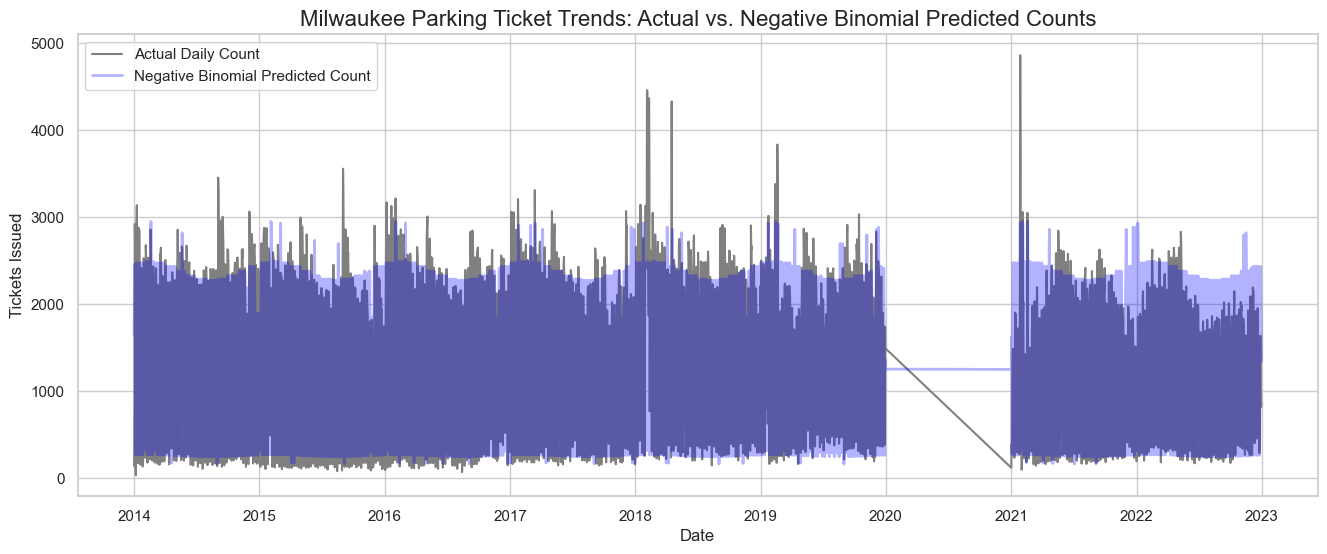

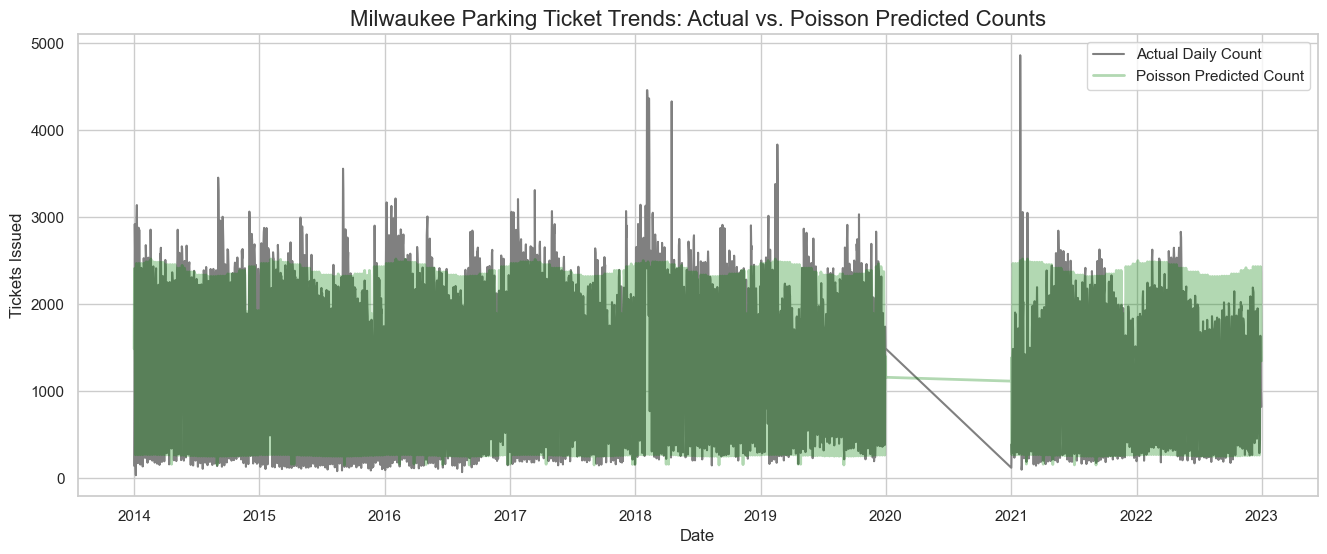

In [75]:
# overlay the logged prediction counts with the actual daily ticket values
# this didnt work very well
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ensure dataframe is sorted by date
daily_summary_df = daily_summary_df.sort_values('join_date').reset_index(drop=True)
# create a plot dataframe that excludes the COVID years
plot_df = daily_summary_df[~daily_summary_df['Year'].isin([2020])]

# plot actual daily counts and overlay predicted counts (assume predicted_tickets column exists)
plt.figure(figsize=(16, 6))
sns.lineplot(data=plot_df, x='join_date', y='total_tickets', color='gray', label='Actual Daily Count')
sns.lineplot(data=plot_df, x='join_date', y='full_nb_predicted_tickets', color='blue', alpha=0.3, linewidth=2, label='Negative Binomial Predicted Count')

plt.title("Milwaukee Parking Ticket Trends: Actual vs. Negative Binomial Predicted Counts", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Tickets Issued")
plt.legend()
plt.show()

# do the same for the Poisson predictions
plt.figure(figsize=(16, 6))
sns.lineplot(data=plot_df, x='join_date', y='total_tickets', color='gray', label='Actual Daily Count')
sns.lineplot(data=plot_df, x='join_date', y='full_poisson_predicted_tickets', color='green', alpha=0.3, linewidth=2, label='Poisson Predicted Count')
plt.title("Milwaukee Parking Ticket Trends: Actual vs. Poisson Predicted Counts", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Tickets Issued")
plt.legend()
plt.show()

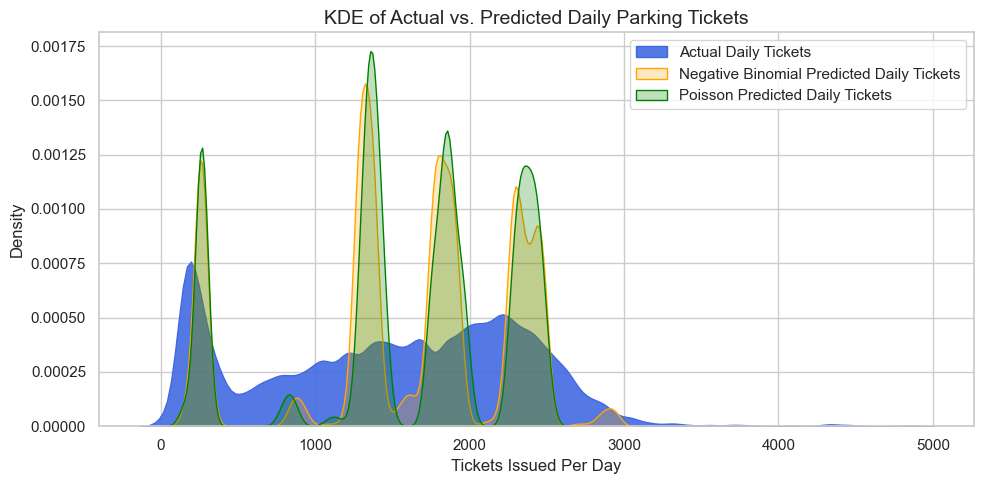

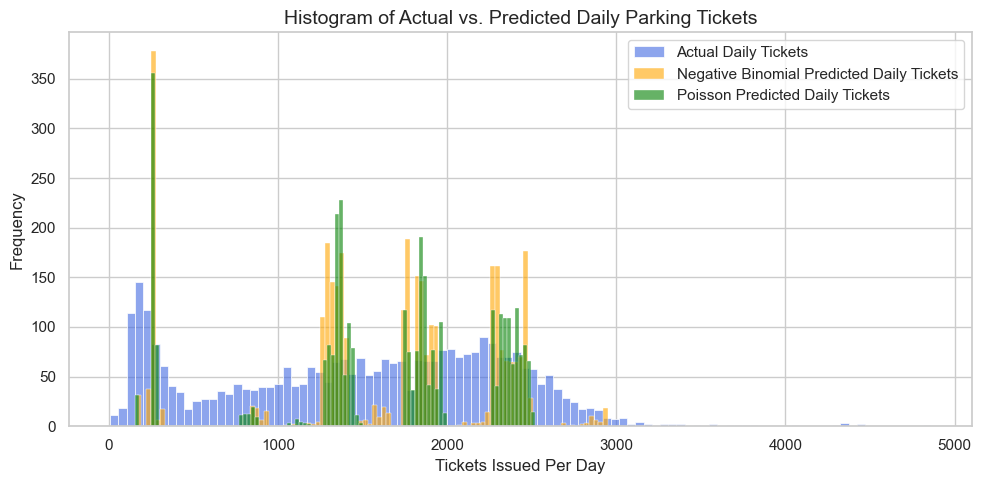

C:\Users\eckbergj\AppData\Local\Temp\ipykernel_25044\3540917155.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=daily_summary_df[['total_tickets', 'full_nb_predicted_tickets', 'full_poisson_predicted_tickets']].melt(var_name='Type', value_name='Tickets'), x='Type', y='Tickets', palette=['royalblue', 'orange', 'green'])


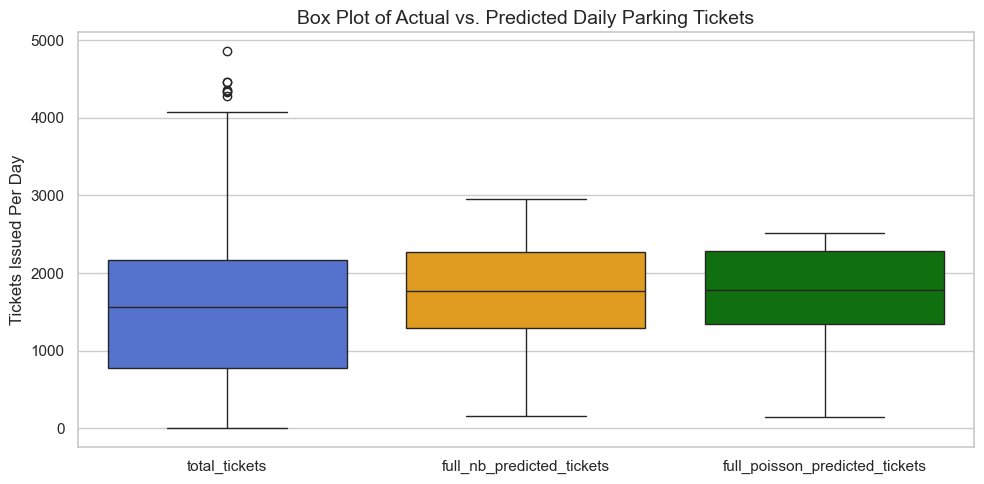

In [66]:
# overlay KDE plot for actual vs. predicted daily ticket counts for both models
plt.figure(figsize=(10, 5))
sns.kdeplot(daily_summary_df['total_tickets'].dropna(), bw_adjust=.3, fill=True, color='royalblue', alpha=0.9, label='Actual Daily Tickets')
sns.kdeplot(daily_summary_df['full_nb_predicted_tickets'].dropna(),bw_adjust=.3, fill=True, color='orange', label='Negative Binomial Predicted Daily Tickets')
sns.kdeplot(daily_summary_df['full_poisson_predicted_tickets'].dropna(), bw_adjust=.3, fill=True, color='green', label='Poisson Predicted Daily Tickets')
plt.title('KDE of Actual vs. Predicted Daily Parking Tickets', fontsize=14)
plt.xlabel('Tickets Issued Per Day')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# do histogram of the count data to prevent smoothing out the count nature of the data with KDE
plt.figure(figsize=(10, 5))
sns.histplot(daily_summary_df['total_tickets'].dropna(), bins=100, color='royalblue', alpha=0.6, label='Actual Daily Tickets')
sns.histplot(daily_summary_df['full_nb_predicted_tickets'].dropna(), bins=100, color='orange', alpha=0.6, label='Negative Binomial Predicted Daily Tickets')
sns.histplot(daily_summary_df['full_poisson_predicted_tickets'].dropna(), bins=100, color='green', alpha=0.6, label='Poisson Predicted Daily Tickets')
plt.title('Histogram of Actual vs. Predicted Daily Parking Tickets', fontsize=14)
plt.xlabel('Tickets Issued Per Day')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# box plot of actual vs. predicted daily ticket counts for both models
plt.figure(figsize=(10, 5))
sns.boxplot(data=daily_summary_df[['total_tickets', 'full_nb_predicted_tickets', 'full_poisson_predicted_tickets']].melt(var_name='Type', value_name='Tickets'), x='Type', y='Tickets', palette=['royalblue', 'orange', 'green'])
plt.title('Box Plot of Actual vs. Predicted Daily Parking Tickets', fontsize=14)
plt.xlabel('')
plt.ylabel('Tickets Issued Per Day')
plt.tight_layout()
plt.show()

In [67]:
daily_summary_df.sample(8)

,join_date,total_tickets,max_temp,min_temp,precipitation,snowfall,is_snow_emergency,is_heavy_rain,WeekDay,Year,...,weekday_cos,day_sin,day_cos,rolling_30d_avg,snow_emergency_label,tickets_bin,predicted_tickets,full_nb_predicted_tickets,poisson_predicted_tickets,full_poisson_predicted_tickets
1922,2019-04-07,342,14.6,7.5,7.9,0.00,0,1,Sunday,2019,...,0.623490,0.988468,0.151428,0.548286,No,"(2.148, 977.4]",410.823660,263.523851,461.750001,268.382047
1321,2017-08-14,977,24.4,15.1,1.3,0.00,0,0,Monday,2017,...,1.000000,0.299363,-0.954139,0.525623,No,"(2.148, 977.4]",1345.209742,1279.134947,1363.084134,1341.663160
3243,2022-11-18,1222,-2.0,-6.3,0.1,0.14,1,0,Friday,2022,...,-0.900969,-0.485302,-0.874347,0.479981,Yes,"(977.4, 1947.8]",1232.576519,2148.526119,1408.090201,1816.047256
2540,2020-12-15,1862,-1.6,-12.2,0.0,0.00,0,0,Tuesday,2020,...,0.623490,0.101168,-0.994869,0.361627,No,"(977.4, 1947.8]",NaN,1891.729883,NaN,1926.821027
60,2014-03-02,180,-11.8,-16.6,0.0,0.07,0,0,Sunday,2014,...,0.623490,0.394356,0.918958,0.723943,No,"(2.148, 977.4]",NaN,317.262169,NaN,274.816748
2546,2020-12-21,972,5.6,-2.4,0.6,0.14,0,0,Monday,2020,...,1.000000,-0.897805,-0.440394,0.377296,No,"(2.148, 977.4]",NaN,1368.758920,NaN,1407.348765
869,2016-05-19,2529,13.3,6.7,0.0,0.00,0,0,Thursday,2016,...,-0.900969,-0.651372,-0.758758,0.711676,No,"(1947.8, 2918.2]",2390.112366,2360.916424,2452.000835,2357.181810
466,2015-04-12,140,10.8,5.0,0.0,0.00,0,0,Sunday,2015,...,0.623490,0.651372,-0.758758,0.691932,No,"(2.148, 977.4]",131.769393,174.696119,103.318289,161.601260
